GOAL: 
1. To understand the fundamental concepts of probabilistic reasoning using a "Simple Bayesian Network." By constructing and analyzing a small network consisting of four variables, such as sleep, happy, donate, and volunteer.
2. This exercise emphasizes how parent nodes influence child nodes and how these dependencies propagate through the network to affect downstream outcomes.

EXPECTED OUTCOMES: 
By the end of the exercise 1, students are expected to 
 1. Define the network structure
 2. Complete Conditional Probability Distribution (CPD) tables so that all probabilities are valid and intuitive
 3. Perform probabilistic inference to compute the likelihood of certain outcomes given specific evidence
 4. Interpret the relationships between variables.

**Install Libraries**

In [1]:
# Install required libraries
!pip install pgmpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 7.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 1.3 MB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [pgmpy]32m4/5 [pgmpy]pl]


**1. Load Libraries**

In [2]:
# ---------------------------------------------------------------
# Import libraries
# ---------------------------------------------------------------
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
import matplotlib.pyplot as plt
import networkx as nx

INFO:numexpr.utils:NumExpr defaulting to 8 threads.


**2. Specify Network**

Note: You need to insert the values in this section

In [3]:

# ---------------------------------------------------------------
# Specify the network
# ---------------------------------------------------------------


# ---------------------------------------------------------------
# 2(a) Define structure
# ---------------------------------------------------------------
model = DiscreteBayesianNetwork([
    ('Sleep', 'Happy'),
    ('Happy', 'Donate'),
    ('Happy', 'Volunteer')
])


# ---------------------------------------------------------------
# 2(b) Define Conditional Probability Distributions (CPD)
# ---------------------------------------------------------------

# P(Sleep)
cpd_sleep = TabularCPD(
    variable='Sleep', variable_card=2,
    values=[[0.7], [0.3]],   # Insert values here
    state_names={'Sleep': ['True', 'False']}
)

# P(Happy | Sleep)
cpd_happy = TabularCPD(
    variable='Happy', variable_card=2,
    values=[[0.8, 0.4],      # Insert values here
            [0.2, 0.6]],     # Insert values here
    evidence=['Sleep'], evidence_card=[2],
    state_names={'Happy': ['True', 'False'], 'Sleep': ['True', 'False']}
)

# P(Donate | Happy)
cpd_donate = TabularCPD(
    variable='Donate', variable_card=2,
    values=[[0.5, 0.1],      # Insert values here
            [0.5, 0.9]],     # Insert values here
    evidence=['Happy'], evidence_card=[2],
    state_names={'Donate': ['True', 'False'], 'Happy': ['True', 'False']}
)

# P(Volunteer | Happy)
cpd_volunteer = TabularCPD(
    variable='Volunteer', variable_card=2,
    values=[[0.6, 0.2],      # Insert values here
            [0.4, 0.8]],     # Insert values here
    evidence=['Happy'], evidence_card=[2],
    state_names={'Volunteer': ['True', 'False'], 'Happy': ['True', 'False']}
)


**3. Describe Network**

In [4]:
# ---------------------------------------------------------------
# Describe network
# ---------------------------------------------------------------

model.add_cpds(cpd_sleep, cpd_happy, cpd_donate, cpd_volunteer)
assert model.check_model(), "Model configuration error!"

# Print all conditional probability tables (similar to 'simple.fit' in R)
for cpd in model.get_cpds():
    print(f"\n{cpd}")


+--------------+-----+
| Sleep(True)  | 0.7 |
+--------------+-----+
| Sleep(False) | 0.3 |
+--------------+-----+

+--------------+-------------+--------------+
| Sleep        | Sleep(True) | Sleep(False) |
+--------------+-------------+--------------+
| Happy(True)  | 0.8         | 0.4          |
+--------------+-------------+--------------+
| Happy(False) | 0.2         | 0.6          |
+--------------+-------------+--------------+

+---------------+-------------+--------------+
| Happy         | Happy(True) | Happy(False) |
+---------------+-------------+--------------+
| Donate(True)  | 0.5         | 0.1          |
+---------------+-------------+--------------+
| Donate(False) | 0.5         | 0.9          |
+---------------+-------------+--------------+

+------------------+-------------+--------------+
| Happy            | Happy(True) | Happy(False) |
+------------------+-------------+--------------+
| Volunteer(True)  | 0.6         | 0.2          |
+------------------+----------

**4. Build a Network**

In [5]:
# ---------------------------------------------------------------
# Build the network and run basic inference
# ---------------------------------------------------------------

# Initialize inference engine
infer = VariableElimination(model)

# Query examples
print("\nP(Happy):")
print(infer.query(variables=['Happy']).values)

print("\nP(Donate | Sleep=True):")
print(infer.query(variables=['Donate'], evidence={'Sleep': 'True'}).values)

print("\nP(Volunteer | Happy=True):")
print(infer.query(variables=['Volunteer'], evidence={'Happy': 'True'}).values)



P(Happy):
[0.68 0.32]

P(Donate | Sleep=True):
[0.42 0.58]

P(Volunteer | Happy=True):
[0.6 0.4]


**5. Visualize Network**

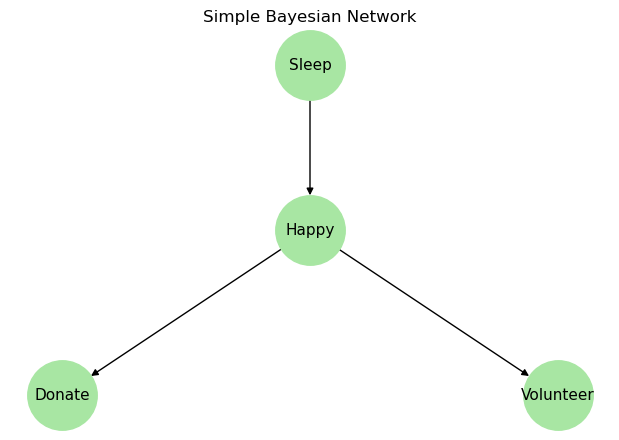

In [6]:
# ---------------------------------------------------------------
# Visualize the network
# ---------------------------------------------------------------


pos = {'Sleep': (0, 2), 'Happy': (0, 1), 'Donate': (-1, 0), 'Volunteer': (1, 0)}

plt.figure(figsize=(6, 4))
nx.draw(model, pos,
        with_labels=True,
        node_color='#a8e6a3',
        node_size=2500,
        arrows=True,
        font_size=11)
plt.title("Simple Bayesian Network", fontsize=12)
plt.show()